## Open notebook in:
| Colab                                 
:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nicolepcx/transformers-the-definitive-guide/blob/master/CH11/ch11_LLM_performance_evaluation.ipynb)                                             

# About This Notebook

This notebook gives you a practical starting point for benchmarking LLM performance on Nebius using the TokenFactory API, or any OpenAI compatible API service. You run Ray based token level benchmarks against two Qwen models: **Qwen3 32B fast** and **Qwen3 32B base**. The goal is to measure real throughput, latency, and stability rather than rely on static claims or marketing numbers.

You can adapt every step to your own environment, your own models, or different cloud providers. Treat this as a starting point for your own benchmarking pipeline, not an endpoint.

NOTE: The cloned repos is adapted from the [original Repo from Ray](https://github.com/ray-project/llmperf/tree/main)

# Install Dependencies

In [1]:
%pip install -U langchain_openai python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.9/484.9 kB 12.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.1
    Uninstalling langchain-core-1.2.1:
      Successfully uninstalled langchain-core-1.2.1


In [2]:
# Imports for API
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
NEBIUS_API_KEY = os.getenv('NEBIUS_API_KEY')


# Clone Repo and Install Dependencies

In [3]:
!git clone https://github.com/Nicolepcx/llmperf.git

Cloning into 'llmperf'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 156 (delta 22), reused 10 (delta 10), pack-reused 112 (from 1)
Receiving objects: 100% (156/156), 253.59 KiB | 3.34 MiB/s, done.
Resolving deltas: 100% (72/72), done.


In [4]:
%cd llmperf

/content/llmperf


In [5]:
!pip install -e .

Obtaining file:///content/llmperf
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.6/158.6 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of litellm to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.0 MB/s eta 0:00:00
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this ru

# Imports

In [6]:
import os
from openai import OpenAI
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Setup Environment

In [7]:
%%sh
export OPENAI_API_KEY="$NEBIUS_API_KEY"
export OPENAI_API_BASE="https://api.tokenfactory.nebius.com/v1"


In [8]:
# Test setup

client = OpenAI(
    base_url="https://api.tokenfactory.nebius.com/v1",
    api_key=os.environ["NEBIUS_API_KEY"],
)

resp = client.chat.completions.create(
    model="Qwen/Qwen3-32B-fast",
    messages=[{"role": "user", "content": "Give me a one sentence summary of transformers."}],
    extra_body={
        "chat_template_kwargs": {"enable_thinking": False},
    },
    max_tokens=64,
    temperature=0.2,
)

print(resp.choices[0].message.content)
print(resp.usage)


Transformers are a type of deep learning model that uses self-attention mechanisms to process sequential data more efficiently and effectively than traditional recurrent neural networks.
CompletionUsage(completion_tokens=30, prompt_tokens=21, total_tokens=51, completion_tokens_details=None, prompt_tokens_details=None)


# Test Fast API

In [10]:
%%bash
export OPENAI_API_KEY="${NEBIUS_API_KEY}"
export OPENAI_API_BASE="https://api.tokenfactory.nebius.com/v1"

python token_benchmark_ray.py \
  --model "Qwen/Qwen3-32B-fast" \
  --mean-input-tokens 1024 \
  --stddev-input-tokens 200 \
  --mean-output-tokens 256 \
  --stddev-output-tokens 32 \
  --max-num-completed-requests 40 \
  --num-concurrent-requests 4 \
  --timeout 600 \
  --llm-api openai \
  --results-dir nebius-qwen32b-fast \
  --additional-sampling-params '{
    "temperature": 0.0,
    "extra_body": {
      "chat_template_kwargs": {"enable_thinking": false}
    }
  }'


\Results for token benchmark for Qwen/Qwen3-32B-fast queried with the openai api.

inter_token_latency_s
    p25 = 0.022191504572799014
    p50 = 0.02337151960922871
    p75 = 0.02499573504978304
    p90 = 0.027618821347946333
    p95 = 0.028935969089224252
    p99 = 0.030252634381620076
    mean = 0.0238663579602365
    min = 0.018620807677782774
    max = 0.030544148746271073
    stddev = 0.002627553918829243
ttft_s
    p25 = 0.5505607774999532
    p50 = 0.5745279989999403
    p75 = 0.5994273597499671
    p90 = 0.6483500560000154
    p95 = 0.7754171707999826
    p99 = 0.9609190665699827
    mean = 0.5973302203749853
    min = 0.4710160450000558
    max = 0.975063600999988
    stddev = 0.09986164088614707
end_to_end_latency_s
    p25 = 1.5796933027500017
    p50 = 1.7231242280000174
    p75 = 1.8033915362499897
    p90 = 2.0187311909999037
    p95 = 2.068302805049939
    p99 = 2.263950471859948
    mean = 1.7225743214749827
    min = 1.3987366599999405
    max = 2.3642260729999407
   

/content/llmperf/token_benchmark_ray.py:166: SyntaxWarning: invalid escape sequence '\R'
  print(f"\Results for token benchmark for {model} queried with the {llm_api} api.\n")
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
2025-12-27 07:04:44,899	INFO worker.py:2007 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_

# Get Stats

In [11]:
summary_path = next(Path("nebius-qwen32b-fast").glob("*_summary.json"))

with open(summary_path, "r") as f:
    summary = json.load(f)

summary_metrics = {
    "Model": summary.get("model"),
    "Mean input tokens": summary.get("mean_input_tokens"),
    "Mean output tokens": summary.get("mean_output_tokens"),
    "Mean TTFT (s)": summary.get("results_ttft_s_mean"),
    "Mean inter token latency (s)": summary.get("results_inter_token_latency_s_mean"),
    "Mean output throughput (tokens/s)": summary.get("results_mean_output_throughput_token_per_s"),
    "Completed requests": summary.get("results_num_completed_requests"),
    "Error rate": summary.get("results_error_rate"),
}

for k, v in summary_metrics.items():
    print(f"{k}: {v}")


Model: Qwen/Qwen3-32B-fast
Mean input tokens: 1024
Mean output tokens: 256
Mean TTFT (s): 0.5973302203749853
Mean inter token latency (s): 0.0238663579602365
Mean output throughput (tokens/s): 300.9494522160338
Completed requests: 40
Error rate: 0.0


# Test Base API

In [12]:
%%bash
export OPENAI_API_KEY="${NEBIUS_API_KEY}"
export OPENAI_API_BASE="https://api.tokenfactory.nebius.com/v1"

python token_benchmark_ray.py \
  --model "Qwen/Qwen3-32B" \
  --mean-input-tokens 1024 \
  --stddev-input-tokens 200 \
  --mean-output-tokens 256 \
  --stddev-output-tokens 32 \
  --max-num-completed-requests 40 \
  --num-concurrent-requests 4 \
  --timeout 600 \
  --llm-api openai \
  --results-dir nebius-qwen32b-base \
  --additional-sampling-params '{
    "temperature": 0.0,
    "extra_body": {
      "chat_template_kwargs": {"enable_thinking": false}
    }
  }'


\Results for token benchmark for Qwen/Qwen3-32B queried with the openai api.

inter_token_latency_s
    p25 = 0.023077161589231128
    p50 = 0.023814582440173978
    p75 = 0.024576054286028576
    p90 = 0.027224884020830866
    p95 = 0.02845499669018635
    p99 = 0.029443746752289043
    mean = 0.024301222576420915
    min = 0.022247590984905845
    max = 0.029533694106720555
    stddev = 0.001868646297647325
ttft_s
    p25 = 0.5748250189998885
    p50 = 0.5976376770000797
    p75 = 0.6500964952498407
    p90 = 0.7142188871998543
    p95 = 0.7907844027500343
    p99 = 1.0213689042199188
    mean = 0.6279607346750083
    min = 0.5284473489998618
    max = 1.1073159349998605
    stddev = 0.10772236934771603
end_to_end_latency_s
    p25 = 5.60247544074997
    p50 = 6.035116769000069
    p75 = 6.499914466749999
    p90 = 7.460720855100021
    p95 = 7.505174017850094
    p99 = 8.195348076039988
    mean = 6.131874919299986
    min = 4.731433074000051
    max = 8.442174927999986
    stddev =

/content/llmperf/token_benchmark_ray.py:166: SyntaxWarning: invalid escape sequence '\R'
  print(f"\Results for token benchmark for {model} queried with the {llm_api} api.\n")
You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
2025-12-27 07:15:22,787	INFO worker.py:2007 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_

# Get Stats

In [13]:
summary_path = next(Path("nebius-qwen32b-base").glob("*_summary.json"))

with open(summary_path, "r") as f:
    summary = json.load(f)

summary_metrics = {
    "Model": summary.get("model"),
    "Mean input tokens": summary.get("mean_input_tokens"),
    "Mean output tokens": summary.get("mean_output_tokens"),
    "Mean TTFT (s)": summary.get("results_ttft_s_mean"),
    "Mean inter token latency (s)": summary.get("results_inter_token_latency_s_mean"),
    "Mean output throughput (tokens/s)": summary.get("results_mean_output_throughput_token_per_s"),
    "Completed requests": summary.get("results_num_completed_requests"),
    "Error rate": summary.get("results_error_rate"),
}

for k, v in summary_metrics.items():
    print(f"{k}: {v}")


Model: Qwen/Qwen3-32B
Mean input tokens: 1024
Mean output tokens: 256
Mean TTFT (s): 0.6279607346750083
Mean inter token latency (s): 0.024301222576420915
Mean output throughput (tokens/s): 136.19304405486815
Completed requests: 40
Error rate: 0.0


In [15]:
def load_summary(results_dir):
    summary_path = next(Path(results_dir).glob("*_summary.json"))
    with open(summary_path, "r") as f:
        return json.load(f)

models = ["Qwen3-32B-fast", "Qwen3-32B"]

fast = load_summary("nebius-qwen32b-fast")
base = load_summary("nebius-qwen32b-base")

throughput = [
    fast["results_mean_output_throughput_token_per_s"],
    base["results_mean_output_throughput_token_per_s"],
]

e2e_latency = [
    fast["results_end_to_end_latency_s_mean"],
    base["results_end_to_end_latency_s_mean"],
]

ttft = [fast["results_ttft_s_mean"], base["results_ttft_s_mean"]]




completed_per_min = [
    fast["results_num_completed_requests_per_min"],
    base["results_num_completed_requests_per_min"],
]

In [ ]:
print(fast.keys())


dict_keys(['version', 'name', 'model', 'mean_input_tokens', 'stddev_input_tokens', 'mean_output_tokens', 'stddev_output_tokens', 'num_concurrent_requests', 'additional_sampling_params_temperature', 'additional_sampling_params_extra_body_chat_template_kwargs_enable_thinking', 'results_inter_token_latency_s_quantiles_p25', 'results_inter_token_latency_s_quantiles_p50', 'results_inter_token_latency_s_quantiles_p75', 'results_inter_token_latency_s_quantiles_p90', 'results_inter_token_latency_s_quantiles_p95', 'results_inter_token_latency_s_quantiles_p99', 'results_inter_token_latency_s_mean', 'results_inter_token_latency_s_min', 'results_inter_token_latency_s_max', 'results_inter_token_latency_s_stddev', 'results_ttft_s_quantiles_p25', 'results_ttft_s_quantiles_p50', 'results_ttft_s_quantiles_p75', 'results_ttft_s_quantiles_p90', 'results_ttft_s_quantiles_p95', 'results_ttft_s_quantiles_p99', 'results_ttft_s_mean', 'results_ttft_s_min', 'results_ttft_s_max', 'results_ttft_s_stddev', 'resul

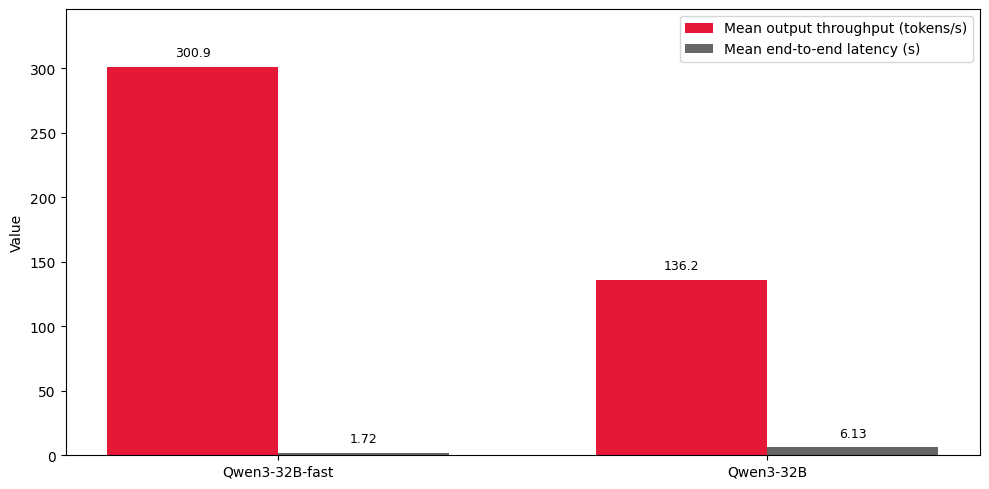

In [18]:
# padding
x = np.arange(len(models))
width = 0.35
ymax = max(max(throughput), max(e2e_latency))
padding = ymax * 0.15

fig, ax = plt.subplots(figsize=(10, 5))

bars_th = ax.bar(
    x - width/2, throughput, width,
    label="Mean output throughput (tokens/s)", color="#E51837"
)
bars_lat = ax.bar(
    x + width/2, e2e_latency, width,
    label="Mean end-to-end latency (s)", color="#666666"
)

ax.set_ylabel("Value")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, ymax + padding)
ax.legend()

def add_labels(bars, fmt="{:.1f}"):
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + (ymax * 0.02),
            fmt.format(h),
            ha="center", va="bottom", fontsize=9
        )

add_labels(bars_th, fmt="{:.1f}")
add_labels(bars_lat, fmt="{:.2f}")

plt.tight_layout()
plt.show()


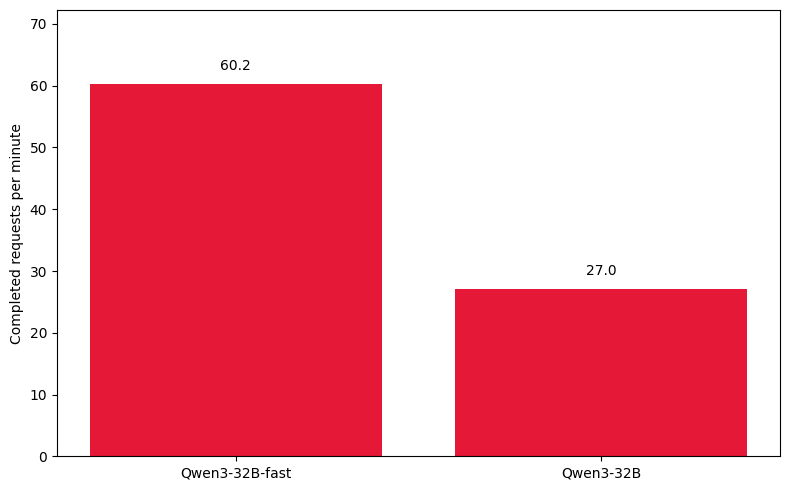

In [19]:
ymax = max(completed_per_min)
padding = ymax * 0.20   # better spacing

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, completed_per_min, color="#E51837")

ax.set_ylabel("Completed requests per minute")
ax.set_ylim(0, ymax + padding)

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + (ymax * 0.03),
        f"{h:.1f}",
        ha="center", va="bottom", fontsize=10
    )

plt.tight_layout()
plt.show()
